In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../data/raw/data.csv")

In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [8]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [9]:
df["Churn_binary"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [10]:
df.groupby("Contract")["Churn_binary"].mean()

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_binary, dtype: float64

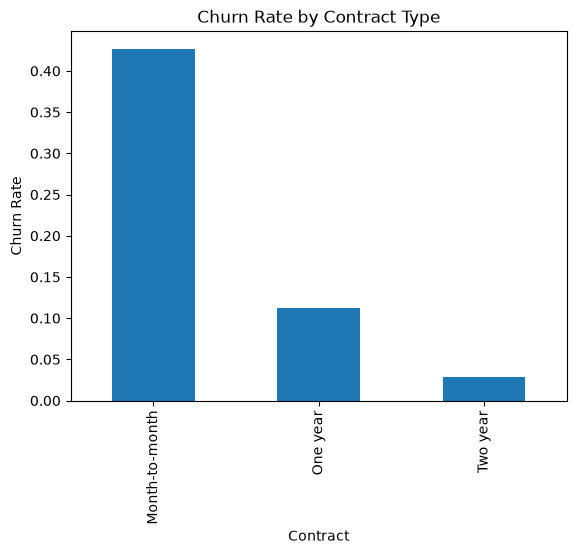

In [11]:
df.groupby("Contract")["Churn_binary"].mean().plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.show()

CONTRACT TYPE:
- so contract type is obviously related to the churn rate.
- month to month have the highest churn rate, which makes sense.

In [12]:
def plot_categorical_churn(df, feature):

    churn_rate = (
        df.assign(
            Churn_binary=df["Churn"].map({
                "No": 0,
                "Yes": 1
            })
        )
        .groupby(feature)["Churn_binary"]
        .mean()
        .sort_values(ascending=False)
    )

    churn_rate.plot(
        kind="bar",
        figsize=(8, 5)
    )

    plt.title(f"Churn Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
def plot_numerical_churn(df, feature):

    churned = df[df["Churn"] == "Yes"][feature]
    stayed = df[df["Churn"] == "No"][feature]

    plt.figure(figsize=(8, 5))

    plt.hist(
        stayed,
        bins=30,
        alpha=0.5,
        label="Stayed"
    )

    plt.hist(
        churned,
        bins=30,
        alpha=0.5,
        label="Churned"
    )

    plt.title(f"{feature} Distribution by Churn")
    plt.xlabel(feature)
    plt.ylabel("Number of Customers")
    plt.legend()
    plt.tight_layout()
    plt.show()

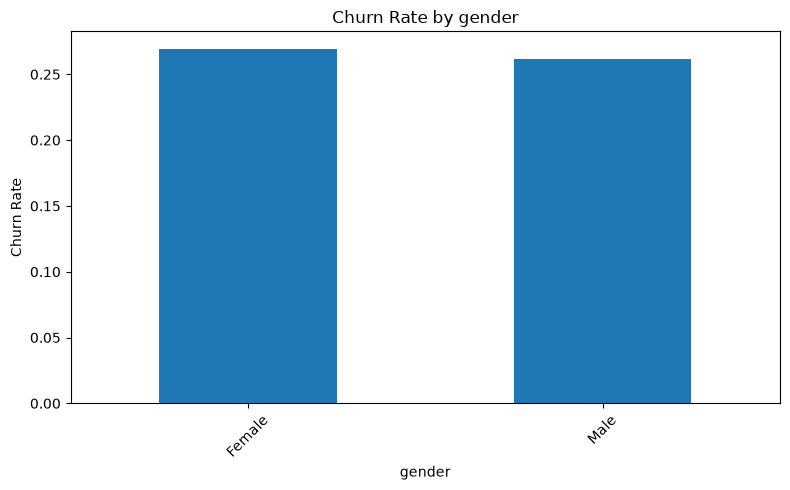

,mean,count
gender,,
Female,0.269209,3488
Male,0.261603,3555


In [18]:
plot_categorical_churn(df, "gender")
df.groupby("gender")["Churn_binary"].agg(
    ["mean", "count"]
)

GENDER:
- gender looks balanced
- 26% vs 27% churn rate is really small
- summary : its a weak feature, but i'll leave it for now.

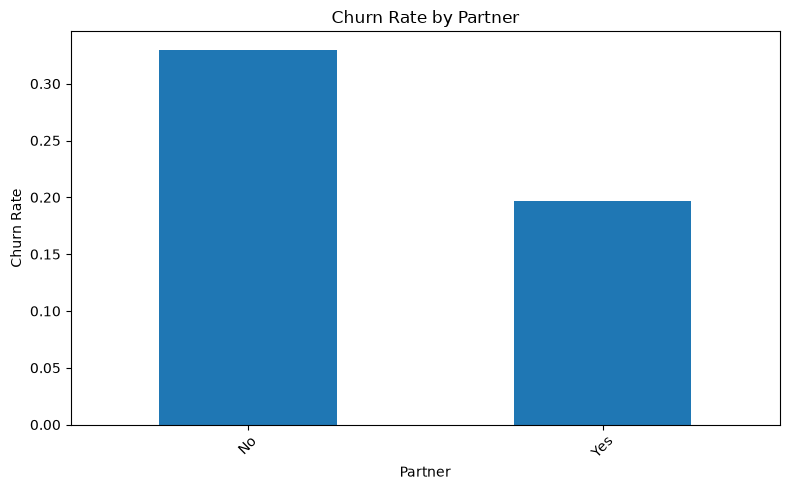

In [35]:
plot_categorical_churn(df, "Partner")

PARTNER: 
- interesting feature. but explains the dependent feature too, since customers who live/ independent are much more likely to churn.

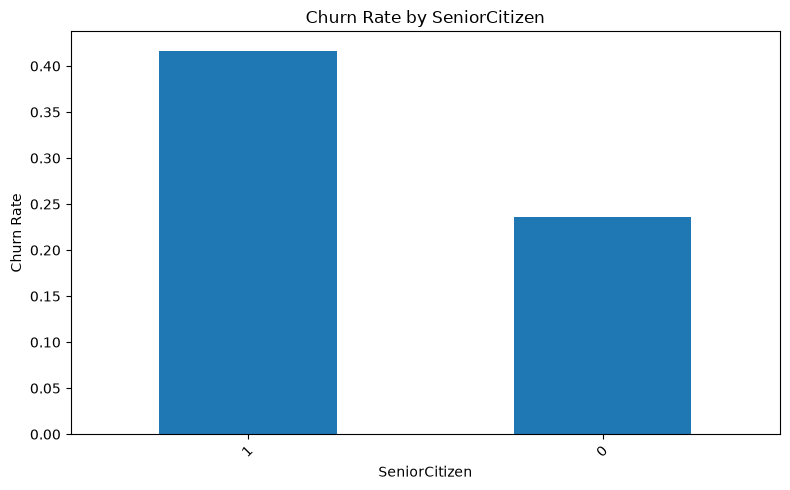

In [20]:
plot_categorical_churn(df, "SeniorCitizen")

SENIOR CITIZEN:
- a strong feature.
- seniors are more likely to churn by around a 20% diff.

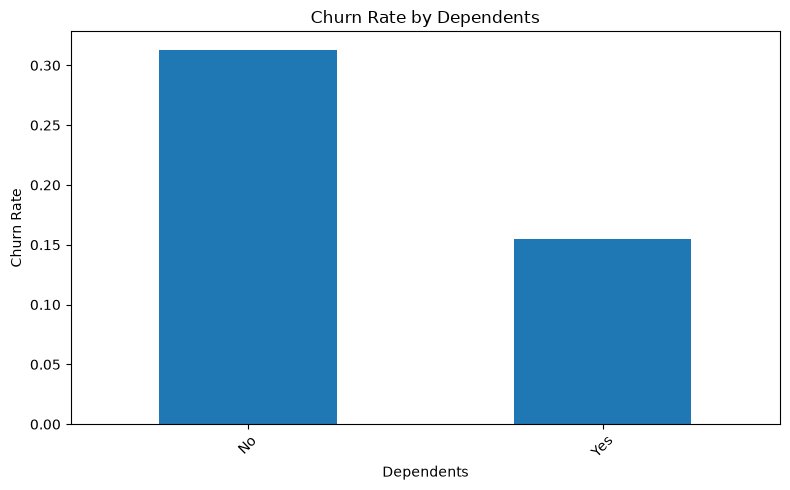

In [21]:
plot_categorical_churn(df, "Dependents")

DEPENDENTS:
- strong feature
- users who are independent are more likely to churn by around 15%

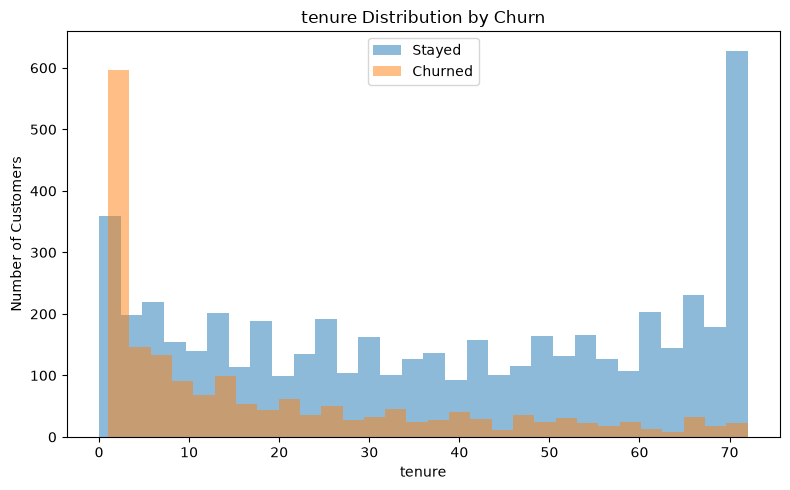

In [22]:
plot_numerical_churn(df, "tenure")

TENURE:
- people who have churned has a positive skew relation. meaning that largest churn rate is for people who have been with the company for one month, and it decreases by tenure.
- there isnt a clear relation for people who stayed by tenure, but definitely >70 months have stayed mostly.
- This suggests tenure may be an important predictor of churn:
  newer customers appear more associated with churn, while long-tenure
  customers appear more associated with retention.

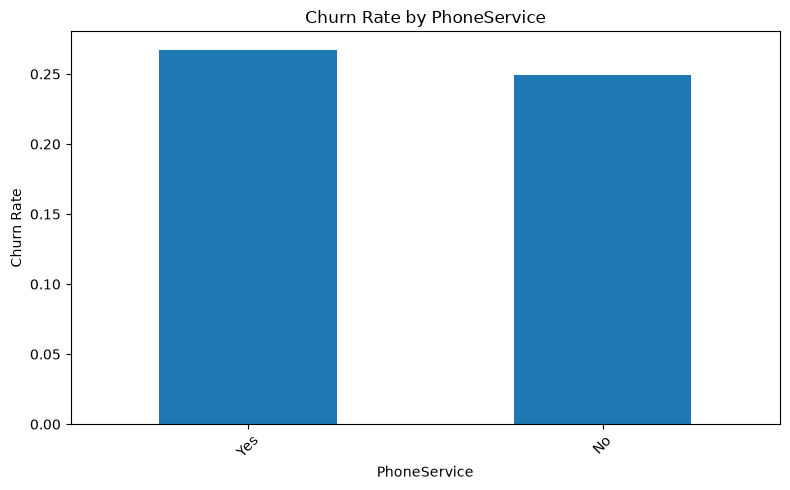

In [23]:
plot_categorical_churn(df, "PhoneService")

PHONE SERVICE:
- similar to gender, theres a small diff
- weak feature.

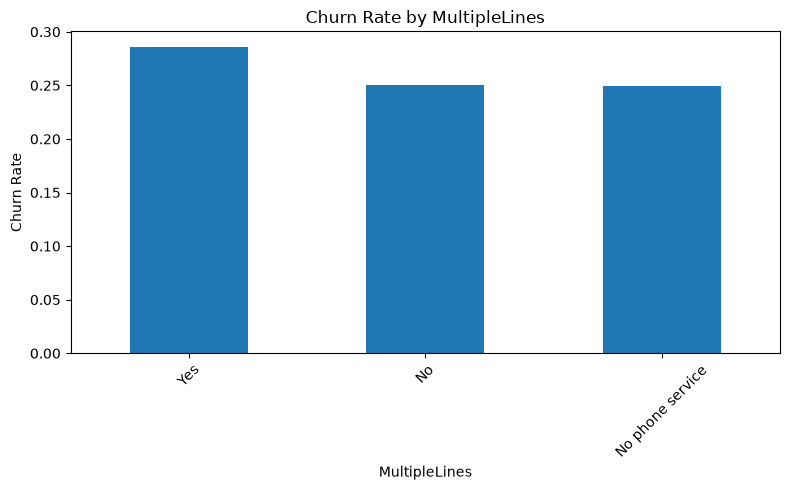

In [24]:
plot_categorical_churn(df, "MultipleLines")

MULTIPLE LINES:
- customers who has multiple lines are more likely to churn than others, but by a minimal diff (4%)
- theres no difference in churn rate between customers who has a single line and no phone service.

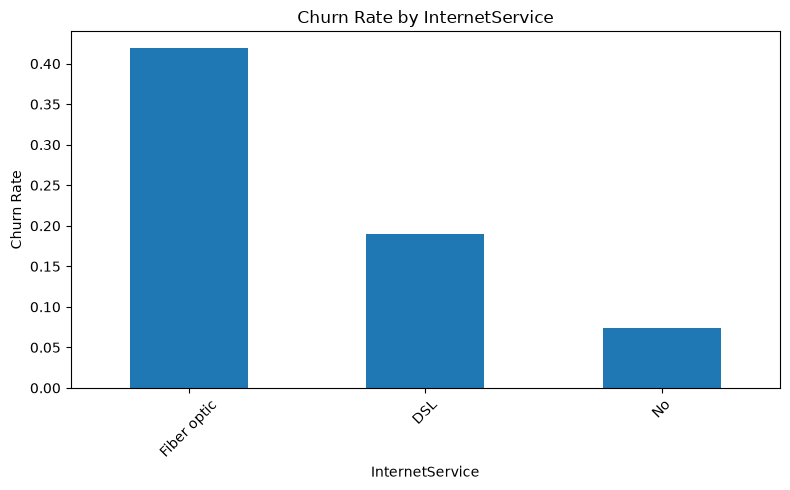

In [25]:
plot_categorical_churn(df, "InternetService")

INTERNET SERVICE:
- very strong feature.
- fiber optic customers are very likely to churn... but why? could it be more expensive? we'll see.

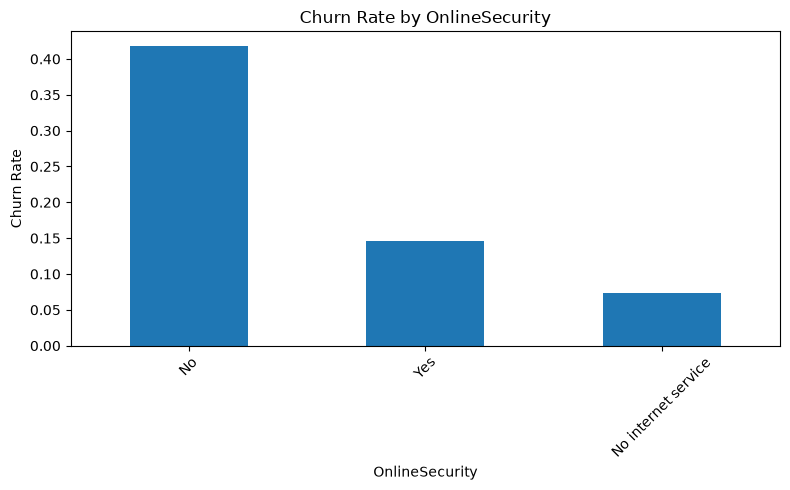

In [26]:
plot_categorical_churn(df, "OnlineSecurity")

ONLINE SECURITY:
- The large difference between no online security and the rest is concerning.
- why does customers with no online security churn more? online security is a good service maybe?

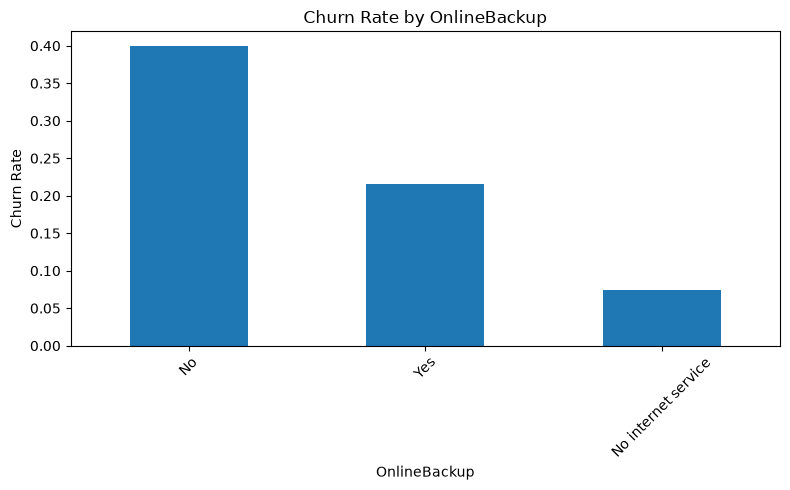

In [27]:
plot_categorical_churn(df, "OnlineBackup")

ONLINE BACKUP:
- Among internet customers, customers with online backup appear to churn
  less than customers without online backup.

- "No internet service" should be treated separately because these customers
  cannot purchase online backup in the first place.

- Customers without internet service appear to have particularly low churn.
  This may relate to other characteristics such as lower monthly charges,
  longer tenure, or different contract types and should be investigated separately.

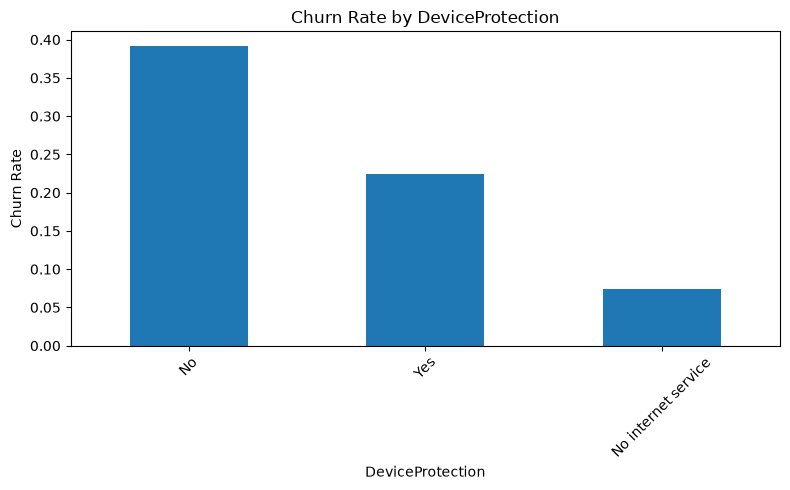

In [29]:
plot_categorical_churn(df, "DeviceProtection")

DEVICE PROTECTION:
- again, the same as every other service (online backup, online security)

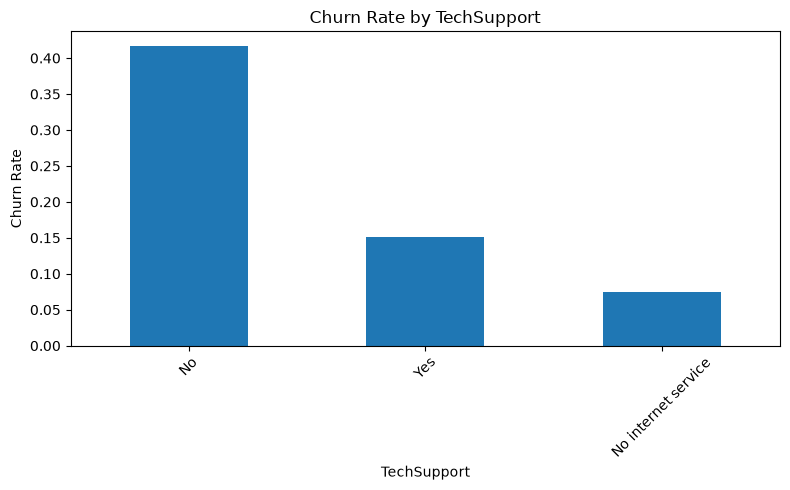

In [30]:
plot_categorical_churn(df, "TechSupport")

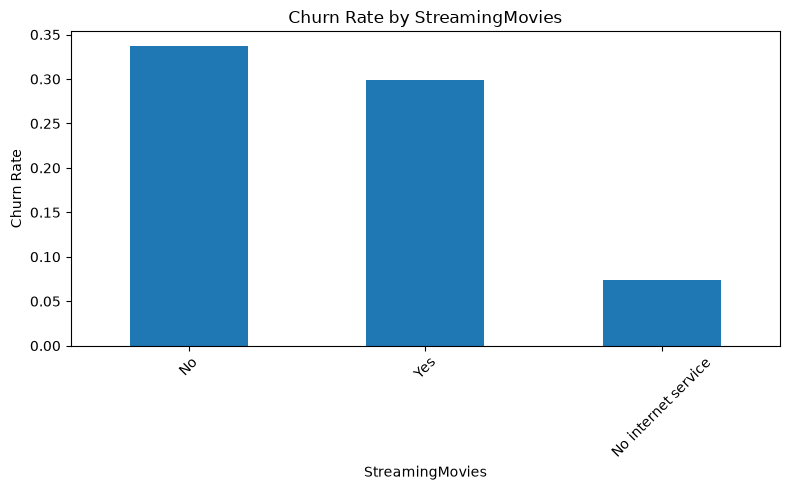

In [31]:
plot_categorical_churn(df, "StreamingMovies")

STREAMING MOVIES:
- this is the only service feature thats quite different from the others, as customers with an internet service have small differnece between streaming movies and not streaming.

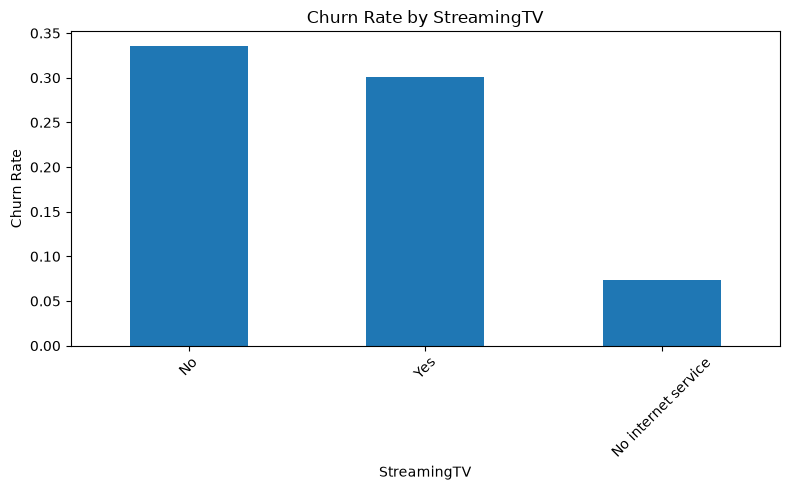

In [32]:
plot_categorical_churn(df, "StreamingTV")

STREAMING TV:
- same as streaming movies

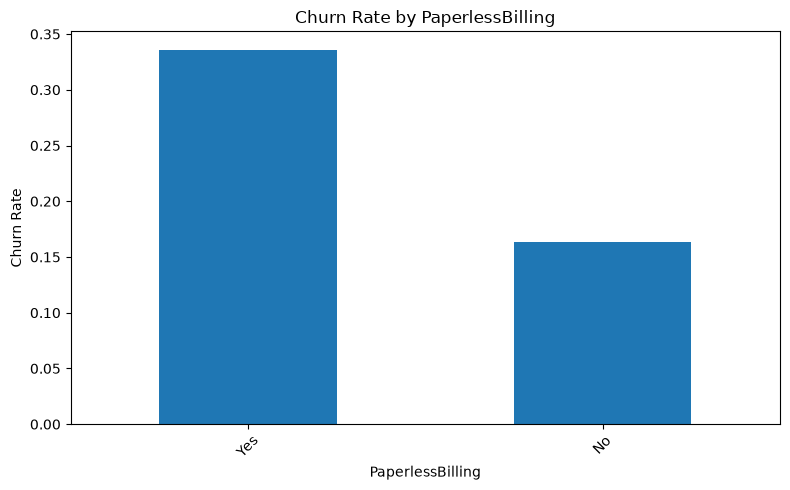

In [33]:
plot_categorical_churn(df, "PaperlessBilling")

Paper less billing:
- customers who pay digitally are much more likely to churn, which sparks the question why do paperbilling customers less likely to churn?
- but def a strong feature

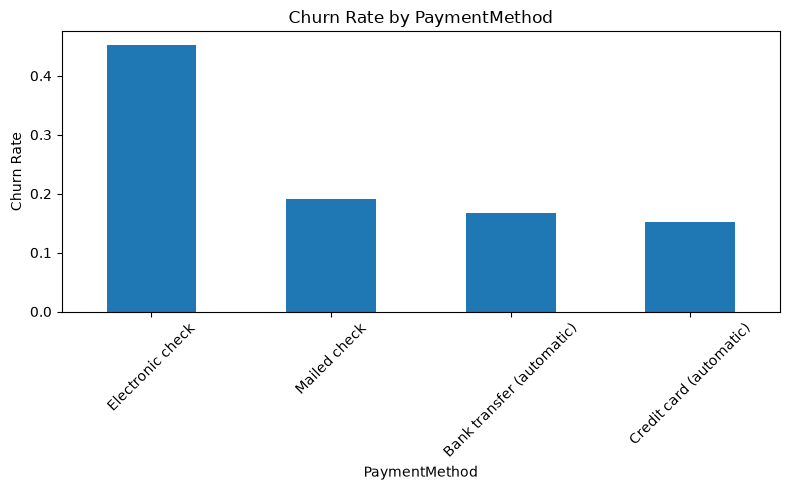

In [34]:
plot_categorical_churn(df, "PaymentMethod")

PAYMENT METHOD:
- very strong feature since it sparks many questions
- automatic methods are less likely to churn , and theyre almost the same so we could put them in the same category.
- electronic checks are alot more likely to churn. Authorization maybe? we'll see.
- I'd like to check later the relation between payment methods and senior citizenship.

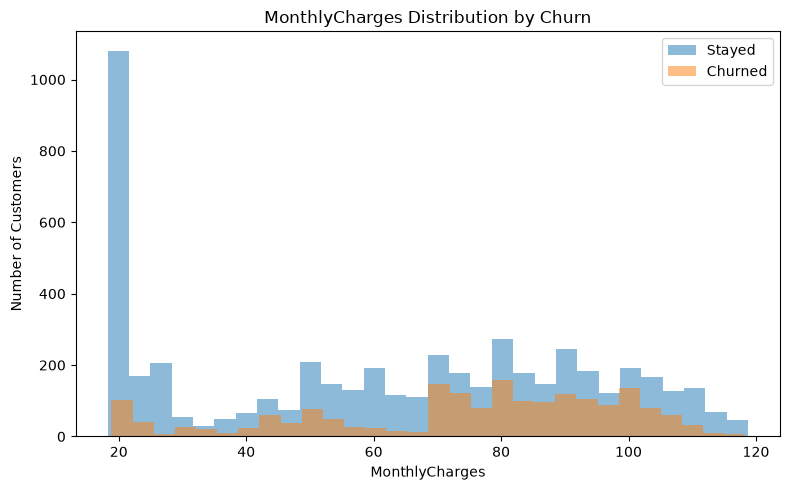

In [36]:
plot_numerical_churn(df, "MonthlyCharges")

MONTHLY CHARGES
- There is no simple linear relationship between MonthlyCharges and churn.
  Churned and retained customers overlap substantially across most charge levels.

- There is a very large concentration of retained customers around ~$20/month.
  This may be related to customers with fewer services or no internet service
  and should be investigated later.

- MonthlyCharges may be more useful when considered together with other features,
  such as InternetService, Contract, or number of subscribed services.

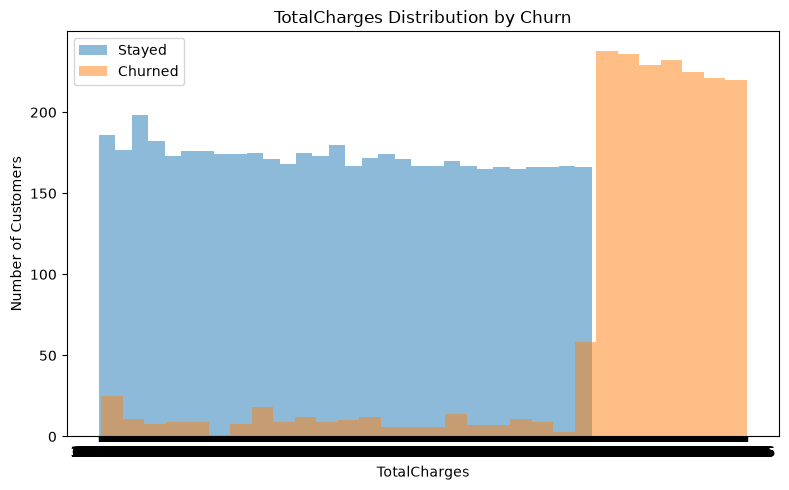

In [39]:
plot_numerical_churn(df, "TotalCharges")

In [40]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [41]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [42]:
df["TotalCharges"].dtype

dtype('float64')

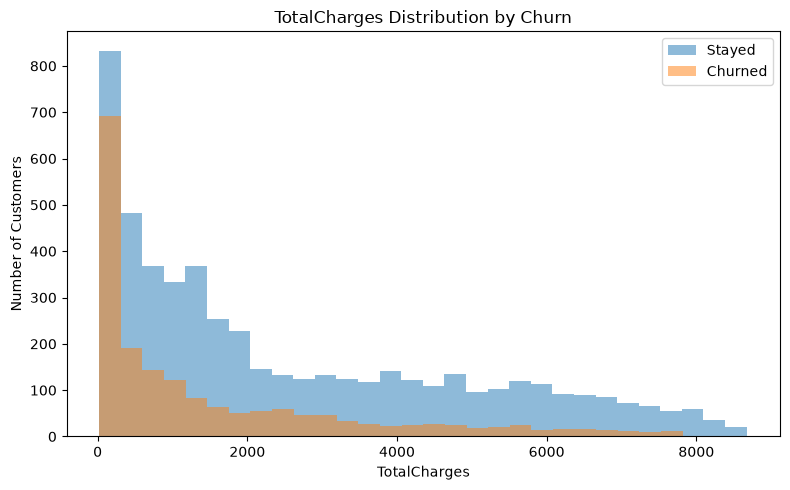

In [43]:
plot_numerical_churn(df, "TotalCharges")

TOTAL CHARGES

- Churned customers are heavily concentrated at low TotalCharges values.
- Customers with high TotalCharges are much more commonly retained.
- This relationship may largely be explained by tenure, because TotalCharges
  accumulates the longer a customer stays with the company.
- Therefore, TotalCharges may overlap strongly with tenure and MonthlyCharges,
  so their relationship should be examined later.